In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from scipy.interpolate import RegularGridInterpolator

from clim_functions import day_plot


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'

dataset = nc.Dataset(fname)

lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))

def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2

dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])

x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [3]:
fp = '/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_tracked.pkl'
df_tracked = pd.read_pickle(fp)
df_tracked['q11'] = [Q[0,0] for Q in df_tracked.Q]
df_tracked['q12'] = [Q[1,0] for Q in df_tracked.Q]
df_tracked['q22'] = [Q[1,1] for Q in df_tracked.Q]

df_tracked


,Day,fnumber,nxc,nyc,Cyc,xc,yc,w,Q,Omega0,...,Rc,psi0,R,AR,eddy_idx,Eddy,next_num,q11,q12,q22
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.000007,...,96.456316,-38.462785,63.384028,1.497688,0,0,79010,0.705472,-0.172995,1.459911
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.000015,...,78.042405,-41.260426,50.068171,1.491752,1,1,79010,1.252542,-0.373183,0.909563
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.000004,...,118.032741,47.992205,74.597458,1.969122,2,2,79010,0.918433,-0.656814,1.558529
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.000016,...,106.666574,75.106895,69.457705,1.207563,3,3,79010,1.091520,-0.174833,0.944157
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.000010,...,103.327517,-44.066805,65.961546,1.519659,4,4,79010,1.300245,-0.375378,0.877456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303158,10650,10641,349.0,158.0,AE,348.663439,158.138527,0.000033,"[[1.3863808771116255, 0.04649055064735413], [0...",0.000016,...,110.552001,-72.997132,43.099927,1.389622,17,79008,79010,1.386381,0.046491,0.722862
303159,10650,10641,973.0,126.0,CE,978.294053,127.970950,-0.000004,"[[0.6233322936879349, -0.5502050858849237], [-...",-0.000001,...,75.127332,4.241051,34.482872,2.273400,18,78991,79010,0.623332,-0.550205,2.089938
303160,10650,10641,805.0,95.0,AE,804.765913,95.382012,0.000011,"[[1.2619918374118362, 0.3980497594289241], [0....",0.000005,...,60.426625,-10.779905,45.893895,1.523600,19,78944,79010,1.261992,0.398050,0.917949
303161,10650,10641,157.0,34.0,CE,157.210669,33.449590,-0.000007,"[[0.9874338034387458, 0.628992620695803], [0.6...",-0.000003,...,141.142981,36.082072,34.764443,1.864486,20,78976,79010,0.987434,0.628993,1.413393


In [4]:
# Clean
df_eddies = df_tracked[['Eddy', 'Day', 'Cyc', 'xc', 'yc', 'w', 'Omega', 'q11', 'q12', 'q22', 'Rc', 'psi0', 'AR', 'R']].copy().sort_values(by=['Eddy', 'Day'])
df_eddies = df_eddies.groupby('Eddy').filter(lambda g: g['Day'].max() - g['Day'].min() >= 21) # Keep only mesoscale - older than 3 weeks
df_eddies['Eddy'] = df_eddies['Eddy'].rank(method='dense').astype(int) # Relabel the Eddy's 1,2,3..
df_eddies = df_eddies.reset_index(drop=True)

# Find Lon and Lat values
xg, yg = x_grid, y_grid
lon_interp = RegularGridInterpolator((yg, xg), lon_rho.T, bounds_error=False, fill_value=np.nan)
lat_interp = RegularGridInterpolator((yg, xg), lat_rho.T, bounds_error=False, fill_value=np.nan)
points = np.column_stack((df_eddies['yc'].to_numpy(), df_eddies['xc'].to_numpy()))
df_eddies['lon'] = lon_interp(points)
df_eddies['lat'] = lat_interp(points)
# Re order columns
cols = df_eddies.columns.tolist()
i = cols.index('Cyc') + 1
base = [c for c in cols if c not in ('lon','lat')]
new_order = base[:i] + ['lon','lat'] + base[i:]
df_eddies = df_eddies[new_order].reset_index(drop=True)
df_eddies

df_eddies


,Eddy,Day,Cyc,lon,lat,xc,yc,w,Omega,q11,q12,q22,Rc,psi0,AR,R
0,1,1462,CE,161.072036,-29.736582,928.181752,1356.070550,-0.000011,-0.000007,0.918433,-0.656814,1.558529,118.032741,47.992205,1.969122,74.597458
1,1,1463,CE,160.820027,-29.753172,905.254559,1345.866439,-0.000018,-0.000009,1.537559,-0.243165,0.688838,108.004573,52.019741,1.602291,68.599374
2,1,1464,CE,160.892701,-29.754904,912.061191,1348.117301,-0.000011,-0.000007,1.237644,-0.119636,0.819551,141.148836,74.035424,1.269457,78.300764
3,1,1465,CE,160.929437,-29.612368,911.162024,1364.461638,-0.000016,-0.000009,1.404286,-0.325607,0.787603,111.650721,56.591801,1.544380,69.625773
4,1,1466,CE,160.908986,-29.586156,908.463829,1366.554462,-0.000014,-0.000009,1.181141,-0.435550,1.007249,115.925719,57.471319,1.538338,72.613632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90189,2826,10645,CE,153.827230,-37.503697,523.889808,304.002300,-0.000024,-0.000007,1.040697,-0.220908,1.007786,105.260907,37.325780,1.245762,48.905621
90190,2826,10647,CE,153.687115,-37.523299,512.684226,297.695084,-0.000027,-0.000008,1.031585,0.002212,0.969387,78.707595,25.393893,1.031663,44.896186
90191,2826,10648,CE,153.699708,-37.537452,514.199660,296.590511,-0.000026,-0.000010,1.010390,0.013422,0.989895,61.298208,19.369553,1.017029,38.796956
90192,2826,10649,CE,153.682657,-37.451789,510.019363,305.068558,-0.000025,-0.000009,1.126718,-0.048147,0.889591,64.546558,19.604126,1.136121,40.028670


In [5]:
# Fill in missing eddy data
def interpolate_eddy_tracks(df):
    df = df.copy()
    df_interp = []

    for eddy_id, group in df.groupby('Eddy'):
        # Build a full range of days for this eddy
        full_days = pd.DataFrame({'Day': range(group['Day'].min(), group['Day'].max() + 1)})
        full_days['Eddy'] = eddy_id

        # Merge to reindex with all days, keeping columns of interest
        merged = pd.merge(full_days, group, on=['Eddy', 'Day'], how='left')

        # Interpolate numerical columns
        merged['lon'] = merged['lon'].interpolate()
        merged['lat'] = merged['lat'].interpolate()
        merged['xc'] = merged['xc'].interpolate()
        merged['yc'] = merged['yc'].interpolate()

        merged['w'] = merged['w'].interpolate()
        merged['Omega'] = merged['Omega'].interpolate()
        merged['q11'] = merged['q11'].interpolate()
        merged['q12'] = merged['q12'].interpolate()
        merged['q22'] = merged['q22'].interpolate()

        merged['Rc'] = merged['Rc'].interpolate()
        merged['psi0'] = merged['psi0'].interpolate()
        merged['AR'] = merged['AR'].interpolate()
        merged['R'] = merged['R'].interpolate()

        # Fill categorical column
        merged['Cyc'] = merged['Cyc'].ffill().bfill()

        df_interp.append(merged)

    df_result = pd.concat(df_interp, ignore_index=True).sort_values(by=['Eddy', 'Day'])

    return df_result

df_eddies = interpolate_eddy_tracks(df_eddies)



In [6]:
df_eddies = df_eddies.groupby('Eddy').filter(lambda g: g['R'].mean() > 15).reset_index(drop=True)

df_eddies['Age'] = df_eddies.groupby('Eddy')['Eddy'].transform('count')

df_eddies['Date'] = pd.Timestamp('1990-01-01') + pd.to_timedelta(df_eddies.Day, unit='D')
fnames = [
    f"/srv/scratch/z3533156/26year_BRAN2020/outer_avg_{1461 + ((day - 1462) // 30) * 30:05}.nc"
    for day in df_eddies['Day']
]
df_eddies['fname'] = fnames

ix = np.abs(df_eddies['xc'].values[:, None] - x_grid).argmin(axis=1)
iy = np.abs(df_eddies['yc'].values[:, None] - y_grid).argmin(axis=1)
idx = df_eddies.columns.get_loc('lat') + 1
df_eddies.insert(idx, 'ic', ix)
df_eddies.insert(idx + 1, 'jc', iy)

df_eddies


,Day,Eddy,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
0,1462,1,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000011,...,0.918433,-0.656814,1.558529,118.032741,47.992205,1.969122,74.597458,107,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,1463,1,CE,160.820027,-29.753172,257,272,905.254559,1345.866439,-0.000018,...,1.537559,-0.243165,0.688838,108.004573,52.019741,1.602291,68.599374,107,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,1464,1,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000011,...,1.237644,-0.119636,0.819551,141.148836,74.035424,1.269457,78.300764,107,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,1465,1,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000016,...,1.404286,-0.325607,0.787603,111.650721,56.591801,1.544380,69.625773,107,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,1466,1,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000014,...,1.181141,-0.435550,1.007249,115.925719,57.471319,1.538338,72.613632,107,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106155,10646,2826,CE,153.757172,-37.513498,182,61,518.287017,300.848692,-0.000026,...,1.036141,-0.109348,0.988587,91.984251,31.359836,1.138712,46.900904,28,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
106156,10647,2826,CE,153.687115,-37.523299,181,60,512.684226,297.695084,-0.000027,...,1.031585,0.002212,0.969387,78.707595,25.393893,1.031663,44.896186,28,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
106157,10648,2826,CE,153.699708,-37.537452,181,60,514.199660,296.590511,-0.000026,...,1.010390,0.013422,0.989895,61.298208,19.369553,1.017029,38.796956,28,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
106158,10649,2826,CE,153.682657,-37.451789,180,62,510.019363,305.068558,-0.000025,...,1.126718,-0.048147,0.889591,64.546558,19.604126,1.136121,40.028670,28,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


<Axes: >

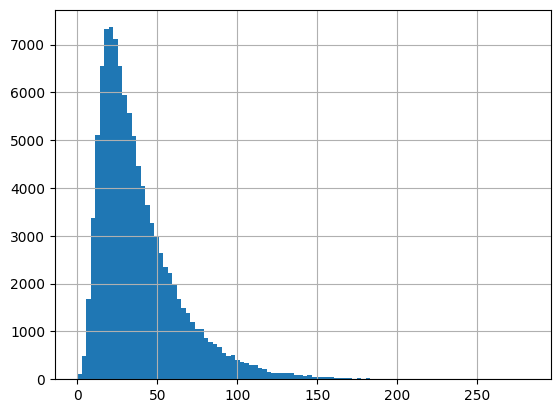

In [7]:
(df_eddies.Rc - df_eddies.R).abs().hist(bins=100)


In [8]:
path = '/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_processed.pkl'
df_eddies.to_pickle(path)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


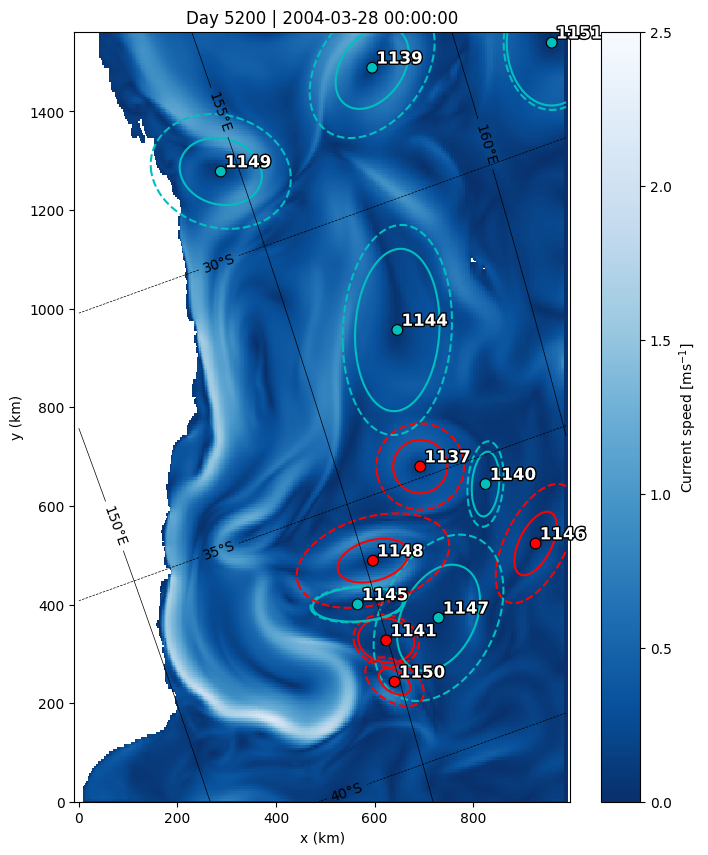

In [33]:
day_plot(5200, df_eddies, out_core_flag=True)
